In [ ]:
!pip install openeo
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.8 MB/s eta 0:00:00


In [ ]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=WNUI-DNMR 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Pengambilan data NO2

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["NO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi);

# Simpan hasil sebagai CSV
result = s5p_no2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_no2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_no2")

0:00:00 Job 'j-26091816142142078d9de40b30592177': send 'start'
0:00:04 Job 'j-26091816142142078d9de40b30592177': created (progress 0%)
0:00:09 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:00:16 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:00:24 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:00:34 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:00:46 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:01:02 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:01:21 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:01:45 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:02:15 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:02:53 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:03:40 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:04:38 Job 'j-26091816142142078d9de40b30592177': finished (progress 100

[PosixPath('output_no2/timeseries.csv'),
 PosixPath('output_no2/job-results.json')]

Pengambilan Data SO₂

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-28", "2026-08-28"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_so2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_so2_aoi = s5p_so2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_so2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_so2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_so2")

0:00:00 Job 'j-2609181620094370a85d9445731a8015': send 'start'
0:00:03 Job 'j-2609181620094370a85d9445731a8015': created (progress 0%)
0:00:09 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:00:15 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:00:23 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:00:33 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:00:46 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:01:01 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:01:21 Job 'j-2609181620094370a85d9445731a8015': running (progress N/A)
0:01:45 Job 'j-2609181620094370a85d9445731a8015': running (progress N/A)
0:02:15 Job 'j-2609181620094370a85d9445731a8015': running (progress N/A)
0:02:52 Job 'j-2609181620094370a85d9445731a8015': running (progress N/A)
0:03:39 Job 'j-2609181620094370a85d9445731a8015': finished (progress 100%)


[PosixPath('output_so2/timeseries.csv'),
 PosixPath('output_so2/job-results.json')]

Pengambilan data CO

In [ ]:
aoi = {
    "type": "Polygon",
    # Paste koordinat yang didapat
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-28", "2026-08-28"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["CO"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_co_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_co_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_co_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_co")

0:00:00 Job 'j-2609181625264f96b28c80c8e8d8cfbe': send 'start'
0:00:03 Job 'j-2609181625264f96b28c80c8e8d8cfbe': created (progress 0%)
0:00:09 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:00:15 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:00:23 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:00:33 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:00:46 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:01:01 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:01:21 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:01:45 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:02:15 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:02:53 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:03:39 Job 'j-2609181625264f96b28c80c8e8d8cfbe': finished (progress 100%)


[PosixPath('output_co/timeseries.csv'),
 PosixPath('output_co/job-results.json')]

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_no2/timeseries.csv")
df.head(10)

,date,feature_index,NO2
0,2025-09-30T00:00:00.000Z,0,NaN
1,2025-10-01T00:00:00.000Z,0,NaN
2,2025-10-02T00:00:00.000Z,0,NaN
3,2025-10-06T00:00:00.000Z,0,0.000014
4,2025-10-04T00:00:00.000Z,0,0.000045
5,2025-10-03T00:00:00.000Z,0,NaN
6,2025-10-05T00:00:00.000Z,0,NaN
7,2025-09-29T00:00:00.000Z,0,NaN
8,2026-01-17T00:00:00.000Z,0,NaN
9,2026-01-15T00:00:00.000Z,0,NaN


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_so2/timeseries.csv")
df.head(10)

,date,feature_index,SO2
0,2026-05-15T00:00:00.000Z,0,NaN
1,2026-05-17T00:00:00.000Z,0,-0.000056
2,2026-05-11T00:00:00.000Z,0,0.000146
3,2026-05-16T00:00:00.000Z,0,NaN
4,2026-05-18T00:00:00.000Z,0,-0.000264
5,2026-05-12T00:00:00.000Z,0,0.000298
6,2026-05-14T00:00:00.000Z,0,0.000166
7,2026-05-13T00:00:00.000Z,0,-0.000675
8,2025-11-06T00:00:00.000Z,0,NaN
9,2025-11-03T00:00:00.000Z,0,NaN


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_co/timeseries.csv")
df.head(10)

,date,feature_index,CO
0,2026-05-02T00:00:00.000Z,0,0.028663
1,2026-04-26T00:00:00.000Z,0,0.023476
2,2026-04-25T00:00:00.000Z,0,0.024172
3,2026-05-01T00:00:00.000Z,0,0.025755
4,2026-04-27T00:00:00.000Z,0,NaN
5,2026-04-29T00:00:00.000Z,0,0.028437
6,2026-04-30T00:00:00.000Z,0,0.033546
7,2026-04-28T00:00:00.000Z,0,NaN
8,2026-01-01T00:00:00.000Z,0,0.029457
9,2025-12-29T00:00:00.000Z,0,0.020568


Normalisasi Tanggal NO2

In [ ]:
import pandas as pd

df = pd.read_csv("output_no2/timeseries.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "NO2": df['NO2']
})

new_df.to_csv("NO2_Timeseries.csv", index=False)

Normalisasi Tanggal SO2

In [ ]:
import pandas as pd

df = pd.read_csv("output_so2/timeseries.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "SO2": df['SO2']
})

new_df.to_csv("SO2_Timeseries.csv", index=False)

In [ ]:
df = pd.read_csv("CO_Timeseries.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

169


In [ ]:
df = pd.read_csv("NO2_Timeseries.csv")
missing_value = df['NO2'].isna().sum()
print(missing_value)

51


In [ ]:
df = pd.read_csv("SO2_Timeseries.csv")
missing_value = df['SO2'].isna().sum()
print(missing_value)

58


In [ ]:
df = pd.read_csv("CO_Timeseries.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

57


Deteksi dan Visualisasi Outlier (Metode IQR) NO2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 7
         date           NO2
25 2025-09-24 -6.785994e-06
64 2025-11-02 -2.512900e-07
65 2025-11-03 -7.859995e-07
68 2025-11-06 -2.390128e-06
69 2025-11-07 -2.924838e-06


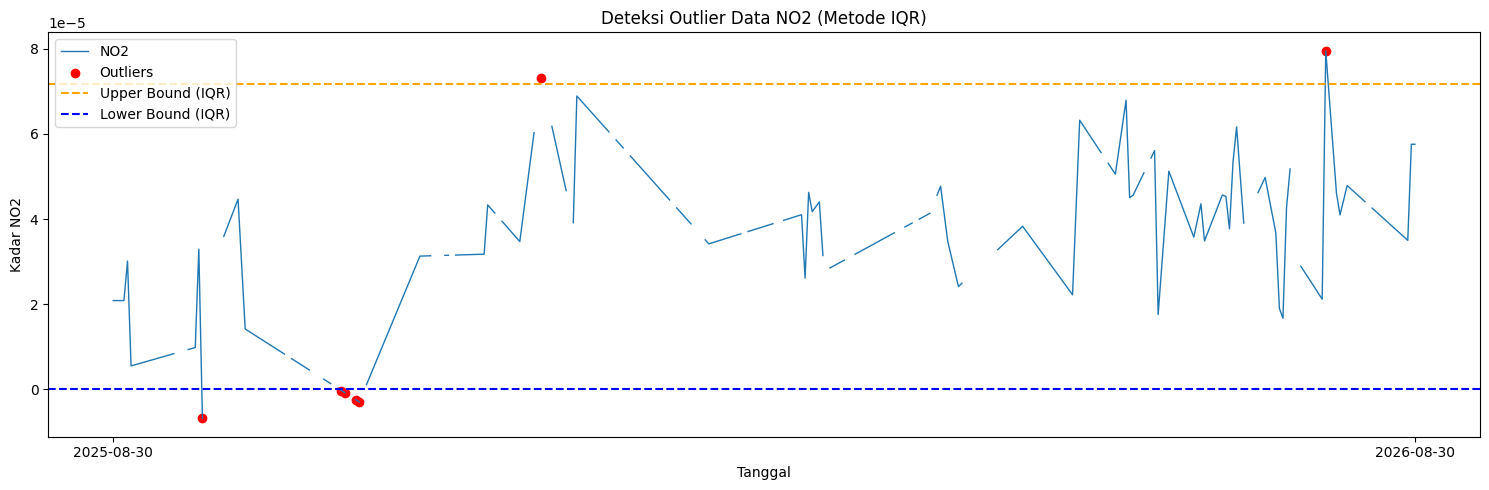

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Deteksi dan Visualisasi Outlier (Metode IQR) SO2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'SO2']].head())

Jumlah Outlier (IQR): 6
          date       SO2
19  2025-09-15  0.000540
40  2025-10-06 -0.000510
165 2026-02-08  0.000546
259 2026-05-13 -0.000675
318 2026-07-11 -0.000506


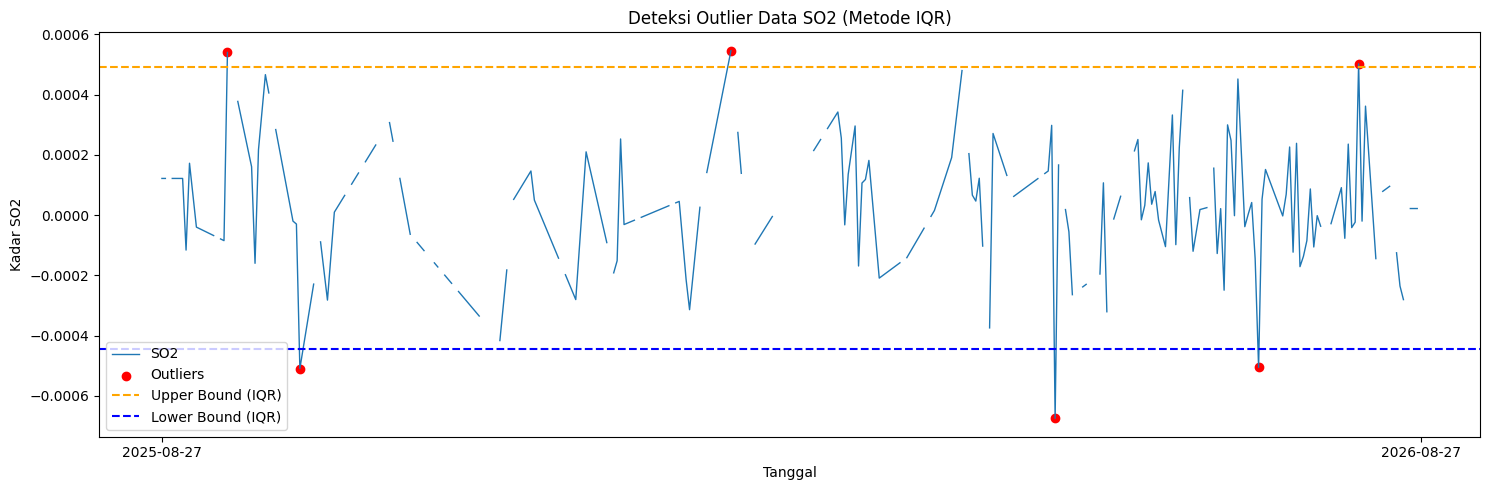

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Deteksi dan Visualisasi Outlier (Metode IQR) CO

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'CO']].head())

Jumlah Outlier (IQR): 5
          date        CO
43  2025-10-09  0.040473
320 2026-07-13  0.040105
347 2026-08-09  0.039287
348 2026-08-10  0.038860
357 2026-08-19  0.038800


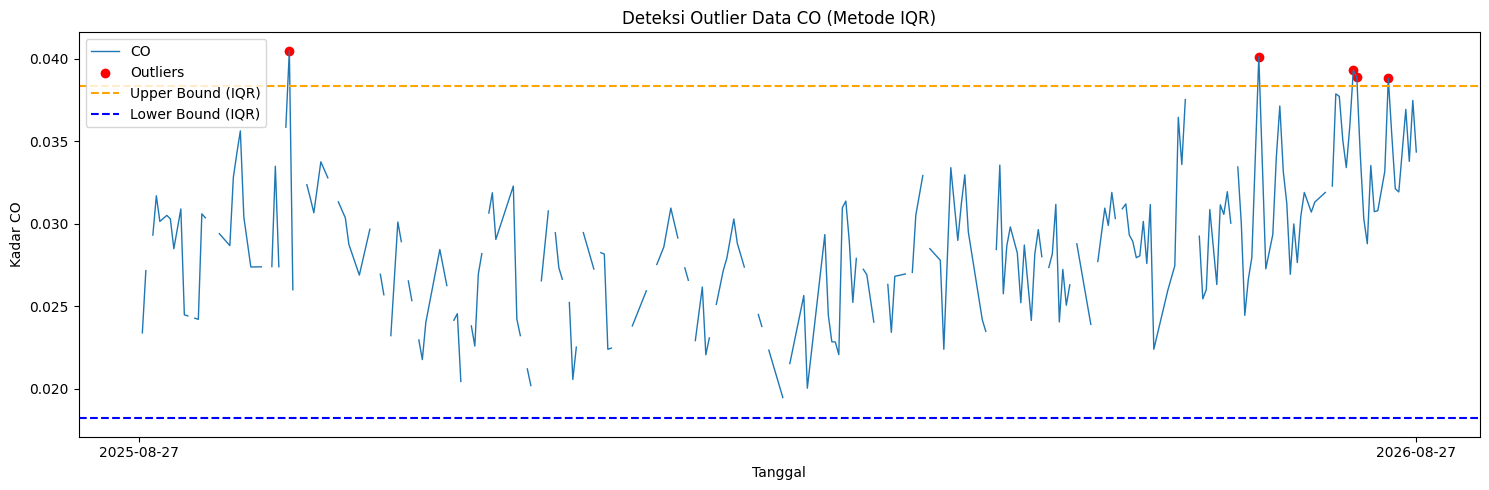

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan Outlier dan Interpolasi Data NO2

In [ ]:
import pandas as pd
import numpy as np

# 1. Ambil data asli
df = pd.read_csv("NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR awal
Q1_init = df['NO2'].quantile(0.25)
Q3_init = df['NO2'].quantile(0.75)
IQR_init = Q3_init - Q1_init
lower_init = Q1_init - 1.5 * IQR_init
upper_init = Q3_init + 1.5 * IQR_init

# 3. Ubah outlier awal menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_init) | (df['NO2'] > upper_init))

# 4. Interpolasi linear
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()

# 5. Algoritma Iteratif untuk Menghilangkan Outlier Baru dengan Pengaman Presisi Desimal
data_final = df['NO2_filled'].copy()
while True:
    Q1_curr = data_final.quantile(0.25)
    Q3_curr = data_final.quantile(0.75)
    IQR_curr = Q3_curr - Q1_curr
    lower_curr = Q1_curr - 1.5 * IQR_curr
    upper_curr = Q3_curr + 1.5 * IQR_curr

    # Deteksi outlier
    outliers = data_final[(data_final < lower_curr) | (data_final > upper_curr)]
    if len(outliers) == 0:
        break # Selesai jika outlier sudah mutlak 0

    # Pangkas dengan margin pengaman kecil (1e-12) agar tidak terbentur masalah limit presisi desimal
    safe_lower = lower_curr + 1e-12
    safe_upper = upper_curr - 1e-12
    data_final = data_final.clip(lower=safe_lower, upper=safe_upper)

# 6. Simpan dataset final yang dijamin bebas outlier secara statistik
df_no2_warudoyong = pd.DataFrame({
    "date": df['date'],
    "NO2": data_final
})
df_no2_warudoyong.to_csv("NO2_Warudoyong_filled.csv", index=False)
print("Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.")

Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load data yang sudah diproses secara iteratif
df = pd.read_csv("NO2_Warudoyong_filled.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR akhir
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Cari outlier akhir
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR) Akhir setelah Capping Iteratif:", len(outliers_iqr))
print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

Jumlah Outlier (IQR) Akhir setelah Capping Iteratif: 0
Batas bawah: 2.6228252636428772e-06
Batas atas: 6.936550308485798e-05


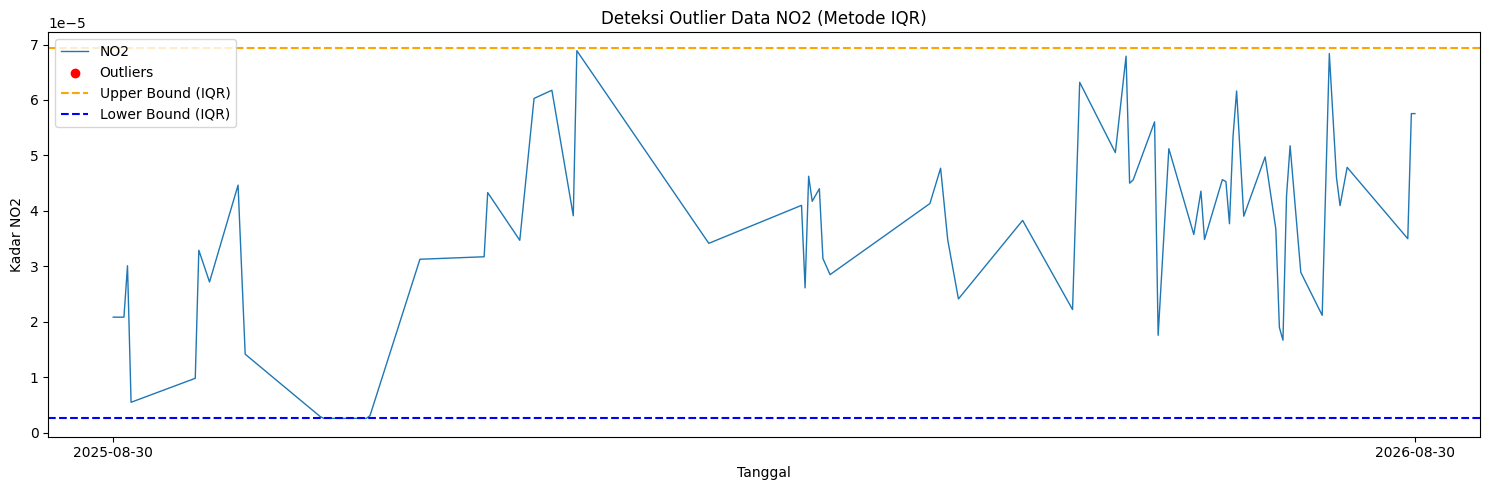

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan Outlier dan Interpolasi Data SO2

In [ ]:
import pandas as pd
import numpy as np

# 1. Ambil data asli
df = pd.read_csv("SO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR awal
Q1_init = df['SO2'].quantile(0.25)
Q3_init = df['SO2'].quantile(0.75)
IQR_init = Q3_init - Q1_init
lower_init = Q1_init - 1.5 * IQR_init
upper_init = Q3_init + 1.5 * IQR_init

# 3. Ubah outlier awal menjadi NaN
df['SO2_cleaned'] = df['SO2'].mask((df['SO2'] < lower_init) | (df['SO2'] > upper_init))

# 4. Interpolasi linear
df['SO2_filled'] = df['SO2_cleaned'].interpolate(method='linear')
df['SO2_filled'] = df['SO2_filled'].bfill().ffill()

# 5. Algoritma Iteratif untuk Menghilangkan Outlier Baru dengan Pengaman Presisi Desimal
data_final = df['SO2_filled'].copy()
while True:
    Q1_curr = data_final.quantile(0.25)
    Q3_curr = data_final.quantile(0.75)
    IQR_curr = Q3_curr - Q1_curr
    lower_curr = Q1_curr - 1.5 * IQR_curr
    upper_curr = Q3_curr + 1.5 * IQR_curr

    # Deteksi outlier
    outliers = data_final[(data_final < lower_curr) | (data_final > upper_curr)]
    if len(outliers) == 0:
        break # Selesai jika outlier sudah mutlak 0

    # Pangkas dengan margin pengaman kecil (1e-12) agar tidak terbentur masalah limit presisi desimal
    safe_lower = lower_curr + 1e-12
    safe_upper = upper_curr - 1e-12
    data_final = data_final.clip(lower=safe_lower, upper=safe_upper)

# 6. Simpan dataset final yang dijamin bebas outlier secara statistik
df_SO2_warudoyong = pd.DataFrame({
    "date": df['date'],
    "SO2": data_final
})
df_SO2_warudoyong.to_csv("SO2_Warudoyong_filled.csv", index=False)
print("Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.")

Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load data yang sudah diproses secara iteratif
df = pd.read_csv("SO2_Warudoyong_filled.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR akhir
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Cari outlier akhir
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier (IQR) Akhir setelah Capping Iteratif:", len(outliers_iqr))
print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

Jumlah Outlier (IQR) Akhir setelah Capping Iteratif: 0
Batas bawah: -0.00046624713750967496
Batas atas: 0.0005028181208357249


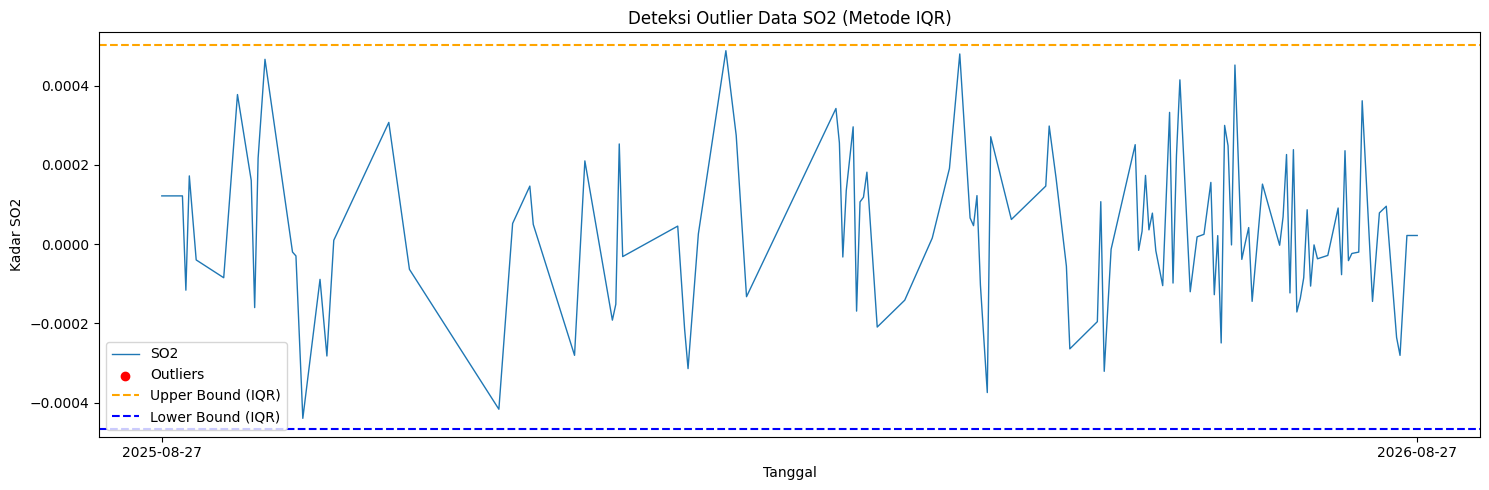

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan Outlier dan Interpolasi Data CO

In [ ]:
import pandas as pd
import numpy as np

# 1. Ambil data asli
df = pd.read_csv("CO_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR awal
Q1_init = df['CO'].quantile(0.25)
Q3_init = df['CO'].quantile(0.75)
IQR_init = Q3_init - Q1_init
lower_init = Q1_init - 1.5 * IQR_init
upper_init = Q3_init + 1.5 * IQR_init

# 3. Ubah outlier awal menjadi NaN
df['CO_cleaned'] = df['CO'].mask((df['CO'] < lower_init) | (df['CO'] > upper_init))

# 4. Interpolasi linear
df['CO_filled'] = df['CO_cleaned'].interpolate(method='linear')
df['CO_filled'] = df['CO_filled'].bfill().ffill()

# 5. Algoritma Iteratif untuk Menghilangkan Outlier Baru dengan Pengaman Presisi Desimal
data_final = df['CO_filled'].copy()
while True:
    Q1_curr = data_final.quantile(0.25)
    Q3_curr = data_final.quantile(0.75)
    IQR_curr = Q3_curr - Q1_curr
    lower_curr = Q1_curr - 1.5 * IQR_curr
    upper_curr = Q3_curr + 1.5 * IQR_curr

    # Deteksi outlier
    outliers = data_final[(data_final < lower_curr) | (data_final > upper_curr)]
    if len(outliers) == 0:
        break # Selesai jika outlier sudah mutlak 0

    # Pangkas dengan margin pengaman kecil (1e-12) agar tidak terbentur masalah limit presisi desimal
    safe_lower = lower_curr + 1e-12
    safe_upper = upper_curr - 1e-12
    data_final = data_final.clip(lower=safe_lower, upper=safe_upper)

# 6. Simpan dataset final yang dijamin bebas outlier secara statistik
df_CO_warudoyong = pd.DataFrame({
    "date": df['date'],
    "CO": data_final
})
df_CO_warudoyong.to_csv("CO_Warudoyong_filled.csv", index=False)
print("Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.")

Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load data yang sudah diproses secara iteratif
df = pd.read_csv("CO_Warudoyong_filled.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR akhir
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Cari outlier akhir
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier (IQR) Akhir setelah Capping Iteratif:", len(outliers_iqr))
print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

Jumlah Outlier (IQR) Akhir setelah Capping Iteratif: 0
Batas bawah: 0.017624364107508457
Batas atas: 0.038392963522875766


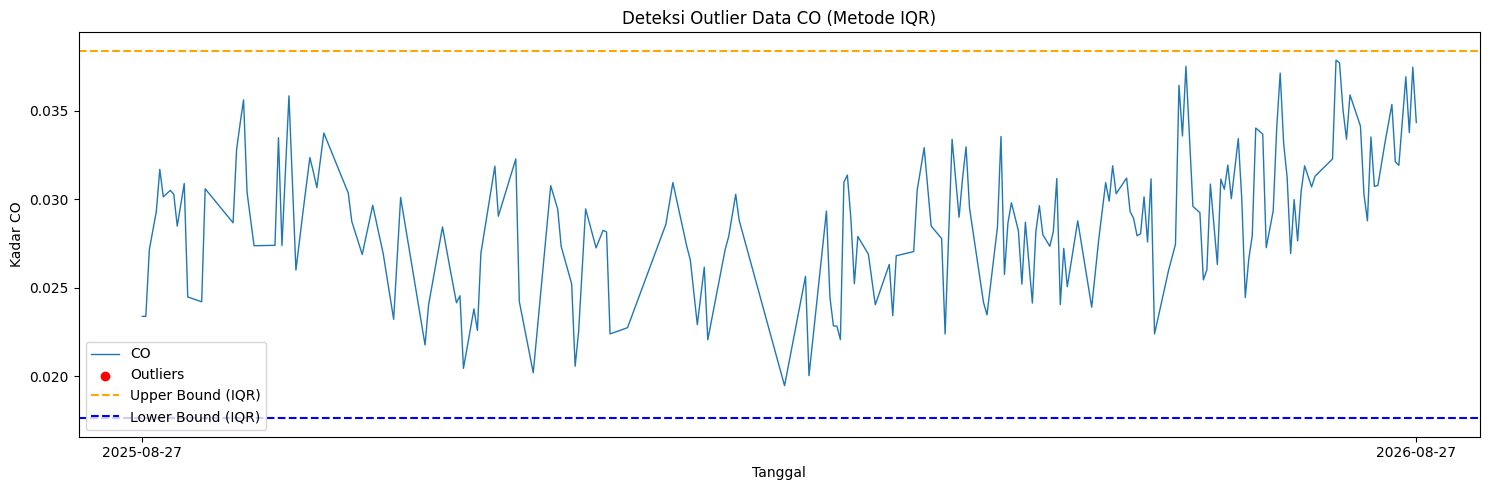

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

EKSTRAKSI FITUR NO2

In [ ]:
!pip install tsfel -q

import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat data yang sudah dibersihkan ----------
df = pd.read_csv('NO2_Warudoyong_filled.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'

# Pastikan data di-casting ke tipe numerik.
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

# Interpolasi terakhir untuk berjaga-jaga apabila terdapat sisa format nan
df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()
fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Inisiasi 68 Daftar Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------

# Fungsi bantuan (helper) merubah output multivariat TSFEL menjadi float tunggal/skalar
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

# Fungsi map pemanggilan fungsi TSFEL
def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Lakukan ekstraksi iteratif pada fitur
row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang diekstrak pada {target_pollutant}: {extracted_features_final.shape[1]}")

# Export hasil ke file CSV
extracted_features_final.to_csv(f'{target_pollutant}_Warudoyong_TSFEL.csv', index=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 63.2 MB/s eta 0:00:00
Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang diekstrak pada NO2: 68


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat data yang sudah dibersihkan ----------
df = pd.read_csv('SO2_Warudoyong_filled.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'SO2'

# Pastikan data di-casting ke tipe numerik.
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

# Interpolasi terakhir untuk berjaga-jaga apabila terdapat sisa format nan
df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()
fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Inisiasi 68 Daftar Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------

# Fungsi bantuan (helper) merubah output multivariat TSFEL menjadi float tunggal/skalar
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

# Fungsi map pemanggilan fungsi TSFEL
def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Lakukan ekstraksi iteratif pada fitur
row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang diekstrak pada {target_pollutant}: {extracted_features_final.shape[1]}")

# Export hasil ke file CSV
extracted_features_final.to_csv(f'{target_pollutant}_Warudoyong_TSFEL.csv', index=False)

Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang diekstrak pada SO2: 68


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat data yang sudah dibersihkan ----------
df = pd.read_csv('CO_Warudoyong_filled.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'CO'

# Pastikan data di-casting ke tipe numerik.
df[target_pollutant] = pd.to_numeric(df[target_pollutant], errors='coerce')

# Interpolasi terakhir untuk berjaga-jaga apabila terdapat sisa format nan
df_clean = df.set_index('date').interpolate(method='time').ffill().bfill()
fs = 1
signal_1d = df_clean[target_pollutant].astype(float).values

# ---------- 2. Inisiasi 68 Daftar Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print("Jumlah fitur yang diminta:", len(FEATURE_LIST))

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------

# Fungsi bantuan (helper) merubah output multivariat TSFEL menjadi float tunggal/skalar
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

# Fungsi map pemanggilan fungsi TSFEL
def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Lakukan ekstraksi iteratif pada fitur
row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])

print(f"Berhasil! Jumlah fitur yang diekstrak pada {target_pollutant}: {extracted_features_final.shape[1]}")

# Export hasil ke file CSV
extracted_features_final.to_csv(f'{target_pollutant}_Warudoyong_TSFEL.csv', index=False)

Jumlah fitur yang diminta: 68
Berhasil! Jumlah fitur yang diekstrak pada CO: 68


In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)
df = pd.read_csv("NO2_Warudoyong_TSFEL.csv")
df.head(10)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,calc_var,dfa,distance,ecdf,ecdf_percentile,ecdf_percentile_count,ecdf_slope,entropy,fundamental_frequency,higuchi_fractal_dimension,hist_mode,human_range_energy,hurst_exponent,interq_range,kurtosis,lempel_ziv,lpcc,max_frequency,max_power_spectrum,maximum_fractal_length,mean_abs_deviation,mean_abs_diff,mean_diff,median_abs_deviation,median_abs_diff,median_diff,median_frequency,mfcc,mse,negative_turning,neighbourhood_peaks,petrosian_fractal_dimension,pk_pk_distance,positive_turning,power_bandwidth,rms,skewness,slope,spectral_centroid,spectral_decrease,spectral_distance,spectral_entropy,spectral_kurtosis,spectral_positive_turning,spectral_roll_off,spectral_roll_on,spectral_skewness,spectral_slope,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,5.329787e-07,0.012644,29.0,1.460216e-09,213.869221,0.000069,0.000035,0.000037,0.000003,0.000016,2.552693e-10,1.256499,365.0,0.015027,0.000034,182.5,32739.118615,0.981357,0.005464,1.559069,0.000039,0.0,0.972563,0.000017,-0.357879,0.128415,0.791776,0.374317,61.505252,-2.906207,0.000012,0.000003,1.005209e-07,0.000008,9.382257e-07,2.499756e-08,0.019126,9.198422,0.815558,21.0,11.0,1.008559,0.000066,22.0,0.114754,0.000038,-0.312558,7.758349e-08,0.083583,-2.495766,-2.471395,0.494387,4.717589,57.0,0.374317,0.0,1.623183,-0.042944,0.122699,0.32963,2.129741e-10,0.000927,0.000002,0.000018,2.05083,0.000018,3.710672e-10,0.0
